(projects-auto-ml-pipe)=
# Projects and automated ML pipeline

This notebook demonstrates how to work with projects, source control (git), and automating the ML pipeline.

Make sure you went over the basics in MLRun [**Quick Start Tutorial**](01-mlrun-basics.ipynb).

MLRun Project is a container for all your work on a particular activity: all the associated code, [functions](https://docs.mlrun.org/en/stable/runtimes/functions.html), [jobs](https://docs.mlrun.org/en/stable/concepts/submitting-tasks-jobs-to-functions.html), [workflows](https://docs.mlrun.org/en/stable/concepts/workflow-overview.html), data, models, and [artifacts](https://docs.mlrun.org/en/stable/store/artifacts.html). Projects can be mapped to `git` repositories to enable versioning, collaboration, and [CI/CD](https://docs.mlrun.org/en/stable/projects/ci-integration.html).

You can create project definitions using the SDK or a yaml file and store those in the MLRun DB, a file, or an archive.
Once the project is loaded you can run jobs/workflows that refer to any project element by name, allowing separation between configuration and code. See [load projects](https://docs.mlrun.org/en/stable/projects/load-project.html) for details.

Projects contain `workflows` that execute the registered functions in a sequence/graph (DAG), and that can reference project parameters, secrets and artifacts by name. MLRun currently supports three workflow engines: `local` (for simple tasks), `remote`, and [`kfp` Kubeflow Pipelines](https://www.kubeflow.org/docs/pipelines/pipelines-quickstart/) (for more complex/advanced tasks). MLRun also supports a real-time workflow engine (see [online serving pipelines (graphs)](https://docs.mlrun.org/en/stable/serving/serving-graph.html). 

An ML Engineer can gather the different functions created by the data engineer and data scientist and create this automated pipeline.

**In this tutorial**
- [**Set up the project and functions**](#set-up-the-project-and-functions)
- [**Work with GIT and archives**](#work-with-git-and-archives)
- [**Build and run automated ML pipelines and CI/CD**](#build-and-run-automated-ml-pipelines-and-cicd)
- [**Test the deployed model endpoint**](#test-the-deployed-model-endpoint)

## MLRun installation and configuration

Before running this notebook make sure the `mlrun` packages are installed (`pip install mlrun`) and that you have configured the access to MLRun service. 

In [ ]:
# Install MLRun if not installed, run this only once (restart the notebook after the install !!!)
%pip install mlrun

<a id="project"></a>
## Set up the project and functions

**Get or create a project**

There are three ways to create/load [**MLRun projects**](https://docs.mlrun.org/en/stable/projects/project.html):
* `mlrun.projects.new_project()`  &mdash; Create a new MLRun project and optionally load it from a yaml/zip/git template.
* `mlrun.projects.load_project()` &mdash; Load a project from a context directory or remote git/zip/tar archive.
* `mlrun.projects.get_or_create_project()` &mdash; Load a project from the MLRun DB if it exists, or from a specified 
  context/archive. 

Projects refer to a `context` directory that holds all the project code and configuration. Its default value is "./", 
which is the directory the MLRun client runs from. 
The `context` dir is 
usually mapped to a `git` repository and/or to an IDE (PyCharm, VSCode, etc.) project.   

In [ ]:
import mlrun

project = mlrun.get_or_create_project(
    "tutorial", context="./", user_project=True, allow_cross_project=True
)

<a id="gs-tutorial-4-step-setting-up-project"></a>

### Register project functions

To run workflows, you must save the definitions for the functions in the project so that function objects are initialized 
automatically when you load a project or when running a project version in automated CI/CD workflows. In addition, you might want to set/register other project attributes such as global parameters, secrets, and data.

Functions are registered using the `set_function()` command, where you can specify the code, requirements, image, etc. 
Functions can be created from a single code/notebook file or have access to the entire project context directory. (By adding the `with_repo=True` flag, it guarantees that the project context is cloned into the function runtime environment).

Function registration examples:

```python
    # Example: register a notebook file as a function
    project.set_function('mynb.ipynb', name='test-function', image="mlrun/mlrun", handler="run_test")

    # Define a job (batch) function that uses code/libs from the project repo
    project.set_function(
        name="myjob", handler="my_module.job_handler",
        image="mlrun/mlrun", kind="job", with_repo=True,
    )
```

**Function code**

Run the following cell to generate the data prep file (or copy it manually):

In [ ]:
%%writefile src/data-prep.py

import pandas as pd
from sklearn.datasets import load_breast_cancer


def breast_cancer_generator():
    """
    A function that generates the breast cancer dataset
    """
    breast_cancer = load_breast_cancer()
    breast_cancer_dataset = pd.DataFrame(
        data=breast_cancer.data, columns=breast_cancer.feature_names
    )
    breast_cancer_labels = pd.DataFrame(data=breast_cancer.target, columns=["label"])
    breast_cancer_dataset = pd.concat(
        [breast_cancer_dataset, breast_cancer_labels], axis=1
    )

    return breast_cancer_dataset, "label"

**Register the function above in the project**

In [ ]:
data_prep_func = project.set_function(
    "src/data-prep.py",
    name="data-prep",
    kind="job",
    image="mlrun/mlrun",
    handler="breast_cancer_generator",
)
pipeline_serving_func = project.set_function(
    func="",
    name="pipeline-serving",
    image="mlrun/mlrun",
    kind="serving",
)

In [ ]:
data_prep_func.save()
pipeline_serving_func.save()

**Register additional project objects and metadata**

You can define other objects (workflows, artifacts, secrets) and parameters in the project and use them in your functions, for example:

```python
    # Register a simple named artifact in the project (to be used in workflows)  
    data_url = 'https://s3.wasabisys.com/iguazio/data/iris/iris.data.raw.csv'
    project.set_artifact('data', target_path=data_url)

    # Add a multi-stage workflow (./workflow.py) to the project with the name 'main' and save the project 
    project.set_workflow('main', "./workflow.py")
    
    # Read env vars from dict or file and set as project secrets
    project.set_secrets({"SECRET1": "value"})
    project.set_secrets(file_path="secrets.env")
    
    project.spec.params = {"x": 5}
```

**Save the project**

In [5]:
project.set_function(f"db://{project.name}/data-prep", name="data-prep")
project.set_function(f"db://{project.name}/pipeline-serving", name="pipeline-serving")
project.set_source(f"db://{project.name}")

In [ ]:
# Save the project in the db (and into the project.yaml file)
project.save()

When you save the project it stores the project definitions in the `project.yaml`. This allows reconstructing the project in a remote cluster or a CI/CD system. 

See the generated project file: <a href="project.yaml">**project.yaml**</a>.

<a id="archives"></a>
## Work with GIT and archives

### Push the project code/metadata into an archive

Use standard git commands to push the current project tree into a git archive. Make sure you `.save()` the project before pushing it.

    git remote add origin <server>
    git commit -m "Commit message"
    git push origin master

Alternatively, you can use MLRun SDK calls:
- `project.create_remote(git_uri, branch=branch)` &mdash; to register the remote Git path
- `project.push()` &mdash; save the project state and commit/push updates to the remote git repo

You can also save the project content and metadata into a local or remote `.zip` archive, for example: 

    project.export("../archive1.zip")
    project.export("s3://my-bucket/archive1.zip")
    project.export(f"v3io://projects/{project.name}/archive1.zip")
    

<a id='load'></a>
### Load a project from local/remote archive 

The project metadata and context (code and configuration) can be loaded and initialized using the {py:meth}`~mlrun.projects.load_project` method.
When `url` (of the git/zip/tar) is specified, it clones a remote repo into the local `context` dir.

    # Load the project and run the 'main' workflow
    project = load_project(context="./", name="myproj", url="git://github.com/mlrun/project-archive.git")
    project.run("main", arguments={'data': data_url})

Projects can also be loaded and executed using the CLI:

    mlrun project -n myproj -u "git://github.com/mlrun/project-archive.git" .
    mlrun project -r main -w -a data=<data-url> .

In [7]:
# load the project in the current context dir
project = mlrun.load_project("./")

<a id="pipeline"></a>
## Build and run automated ML pipelines and CI/CD

A pipeline is created by running an MLRun **"workflow"**.
The following code defines a workflow and writes it to a file in your local directory, with the file name **workflow.py**.
The workflow describes a directed acyclic graph (DAG) which is executed using the `local`, `remote`, or `kubeflow` engines.

See [running a multi-stage workflow](https://docs.mlrun.org/en/stable/concepts/workflow-overview.html).
The defined pipeline includes the following steps:

- Generate/prepare the data (`ingest`).
- Train and the model (`train`).
- Deploy the model as a real-time serverless function (`serving`).

```{admonition} Note
A pipeline can also include continuous build integration and deployment (CI/CD) steps, such as building container images and deploying models.
```

In [ ]:
%%writefile 'src/workflow.py'

from kfp import dsl
import mlrun

# Create a Kubeflow Pipelines pipeline
@dsl.pipeline(name="breast-cancer-demo")
def pipeline(model_name="cancer-classifier"):
    # Run the ingestion function with the new image and params
    ingest = mlrun.run_function(
        "data-prep",
        name="get-data",
        returns=["dataset", "label_column"],
    )

    # Train a model using the auto_trainer hub function
    train = mlrun.run_function(
        "hub://auto_trainer",
        inputs={"dataset": ingest.outputs["dataset"]},
        params = {
            "model_class": "sklearn.ensemble.RandomForestClassifier",
            "train_test_split_size": 0.2,
            "label_columns": "label",
            "model_name": model_name,
        }, 
        handler='train',
        outputs=["model"],
    )

    # Deploy the trained model as a serverless function
    mlrun.deploy_function(
        "pipeline-serving",
        models=[
            {
                "key": model_name,
                "model_path": train.outputs["model"],
                "class_name": 'mlrun.frameworks.sklearn.SKLearnModelServer',
            }
        ],
    )

In [ ]:
project.set_workflow(name="main", workflow_path="./src/workflow.py", embed=True)
project.save()

<a id="gs-tutorial-4-step-register-workflow"></a>

**Run the workflow**

> 2025-05-18 12:52:08,435 [info] Submitting remote workflow: {"project_name":"tutorial-shapira","schedule":null,"workflow_engine":"kfp"}


> 2025-05-18 12:52:19,173 [info] Started run workflow tutorial-shapira-main with run id = '8902f0f5-b1db-4095-99b8-e86da84857fa' by remote engine
> 2025-05-18 12:52:19,174 [info] Waiting for pipeline run completion: {"project":"tutorial-shapira","run_id":"8902f0f5-b1db-4095-99b8-e86da84857fa"}


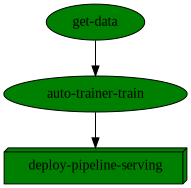

uid,start,end,state,kind,name,parameters,results
...7868e462,May 18 12:53:13,2025-05-18 12:53:18.616713+00:00,completed,run,auto-trainer-train,model_class=sklearn.ensemble.RandomForestClassifiertrain_test_split_size=0.2label_columns=labelmodel_name=cancer-classifier,accuracy=0.956140350877193f1_score=0.9673202614379085precision_score=0.9487179487179487recall_score=0.9866666666666667
...cd614144,May 18 12:52:38,2025-05-18 12:52:41.216559+00:00,completed,run,get-data,,label_column=label


In [10]:
# Run the workflow
run_id = project.run(
    "main",
    arguments={"model_name": "cancer-classifier"},
    engine="remote",
    watch=True,
)

<br>

**View the pipeline in MLRun UI**

![workflow](./_static/images/workflow.png)

<br>

**Run workflows using the CLI**

With MLRun you can use a single command to load the code from local dir or remote archive (Git, zip, ..) and execute a pipeline. This can be very useful for integration with CI/CD frameworks and practices. See [CI/CD integration](https://docs.mlrun.org/en/stable/projects/ci-integration.html) for more details.

The following command loads the project from the current dir (`.`) and executes the workflow with an argument, for running on k8s.

    mlrun project -r ./workflow.py -w -a model_name=classifier2 .

<a id="test-model"></a>
## Test the deployed model endpoint

Now that your model is deployed using the pipeline, you can invoke it as usual:

In [11]:
serving_fn = project.get_function("pipeline-serving")

In [12]:
# Create a mock (simulator of the real-time function)
my_data = {
    "inputs": [
        [
            1.371e01,
            2.083e01,
            9.020e01,
            5.779e02,
            1.189e-01,
            1.645e-01,
            9.366e-02,
            5.985e-02,
            2.196e-01,
            7.451e-02,
            5.835e-01,
            1.377e00,
            3.856e00,
            5.096e01,
            8.805e-03,
            3.029e-02,
            2.488e-02,
            1.448e-02,
            1.486e-02,
            5.412e-03,
            1.706e01,
            2.814e01,
            1.106e02,
            8.970e02,
            1.654e-01,
            3.682e-01,
            2.678e-01,
            1.556e-01,
            3.196e-01,
            1.151e-01,
        ]
    ]
}
serving_fn.invoke("/v2/models/cancer-classifier/infer", body=my_data)

{'id': '68d536ee-c546-41c9-9a98-03cdc0dc78a8',
 'model_name': 'cancer-classifier',
 'outputs': [0],
 'timestamp': '2025-05-18 12:56:19.804983+00:00',
 'model_endpoint_uid': '26b8e62c2fc7434b948c23f43a4abdc3'}

## Done!

Congratulations! You’ve completed Part 4 of the MLRun getting-started tutorial. To continue, proceed to [**Part 5 Model monitoring**](05-model-monitoring.ipynb).

You might also want to explore the following demos:
- For an example of distributed training pipeline using TensorFlow, Keras, and PyTorch, see the [**mask detection demo**](https://github.com/mlrun/demo-mask-detection).
- To learn about using the feature store to process raw transactions and events in real-time and respond and block transactions before they occur, see the [**Fraud prevention demo**](https://github.com/mlrun/demo-fraud).  